# 🚕 Q-Learning en Taxi-v4 — Trabajo en casa

En este ejercicio aplicará Q-Learning al ambiente **Taxi-v4** de Gymnasium.

La lógica es la misma trabajada en FrozenLake:

$$
(s_t,a_t) \rightarrow (r_{t+1},s_{t+1})
$$

y la actualización:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\alpha
\left[
r_{t+1}
+
\gamma \max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right]
$$

## Objetivo

Implementar y analizar un agente Q-Learning capaz de aprender a recoger un pasajero y llevarlo a su destino.


## 1. Preparación

Instale Gymnasium si es necesario:

```bash
pip install gymnasium[toy-text]
```


In [ ]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

from IPython.display import HTML
from matplotlib import animation


## 2. Crear el ambiente

Taxi tiene un número de estados mucho mayor que FrozenLake.

Cada estado codifica:

- posición del taxi,
- ubicación del pasajero,
- destino del pasajero.

Las acciones posibles son:

| Acción | Significado |
|---|---|
| 0 | South |
| 1 | North |
| 2 | East |
| 3 | West |
| 4 | Pickup |
| 5 | Dropoff |


In [ ]:
env = gym.make("Taxi-v4", render_mode="rgb_array")

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)


Número de estados: 500
Número de acciones: 6


### Pregunta 1

¿Cuántos estados y cuántas acciones tiene Taxi-v4?

Explique brevemente por qué Taxi tiene muchos más estados que FrozenLake.


**Respuesta 1**

Taxi-v4 tiene **500 estados** y **6 acciones**. Tiene muchos más estados que FrozenLake porque un estado aquí no guarda solo dónde está el taxi (25 casillas), sino también dónde está el pasajero (5 opciones: las 4 paradas o dentro del taxi) y cuál es su destino (4 paradas). Multiplicando: 25 × 5 × 4 = 500.

En FrozenLake el estado es únicamente la casilla del agente, porque no hay nada más que recordar.

## 3. Observar una interacción

Ejecute una acción aleatoria y observe qué devuelve el ambiente.


In [ ]:
state, info = env.reset(seed=42)

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Estado:", state)
print("Acción:", action)
print("Nuevo estado:", next_state)
print("Recompensa:", reward)
print("Terminated:", terminated)


Estado: 386
Acción: 1
Nuevo estado: 286
Recompensa: -1
Terminated: False


### Pregunta 2

En la interacción anterior identifique:

$$
s_t,\quad a_t,\quad r_{t+1},\quad s_{t+1}
$$

¿Qué representa cada elemento?


**Respuesta 2**

- $s_t$ = **Estado** (386 con `seed=42`): la situación actual, es decir, dónde está el taxi, dónde el pasajero y cuál es el destino, todo codificado en un número.
- $a_t$ = **Acción**: el movimiento que se escogió al azar (0–5: sur, norte, este, oeste, recoger o dejar).
- $r_{t+1}$ = **Recompensa**: la nota que da el ambiente por esa acción. Cada paso normal cuesta −1, para castigar la demora.
- $s_{t+1}$ = **Nuevo estado**: la situación en la que queda el taxi después de ejecutar la acción.

## 4. Inicializar la Q-table

Cada fila corresponde a un estado y cada columna a una acción.

Inicialmente:

$$
Q(s,a)=0
$$


In [ ]:
n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

print("Shape de Q:", Q.shape)
Q[:5]


Shape de Q: (500, 6)


array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

### Pregunta 3

¿Cuántos valores debe aprender el agente en total?

Calcule:

$$
|\mathcal{S}| \times |\mathcal{A}|
$$


**Respuesta 3**

El agente debe aprender un valor por cada combinación de estado y acción:

$$|\mathcal{S}| \times |\mathcal{A}| = 500 \times 6 = 3\,000$$

Son los 3 000 números de la Q-table. Cada uno responde a la pregunta: *"estando en este estado, ¿qué tan buena es esta acción a largo plazo?"*.

## 5. Política $\epsilon$-greedy

Implemente una función que:

- con probabilidad $\epsilon$ seleccione una acción aleatoria;
- en otro caso seleccione:

$$
\arg\max_a Q(s,a)
$$

### Actividad 1
Complete la función.


In [ ]:
def choose_action(Q, state, epsilon, env):
    # Con probabilidad epsilon exploramos: acción al azar.
    if random.random() < epsilon:
        return env.action_space.sample()

    # En caso contrario explotamos: la acción con mayor valor Q en ese estado.
    return int(np.argmax(Q[state]))


## 6. Actualización de Q

La regla de actualización es:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+
\gamma\max_{a'}Q(s',a')
-
Q(s,a)
\right]
$$

### Actividad 2
Complete la función.


In [ ]:
def update_q(Q, state, action, reward, next_state, alpha, gamma):
    # Target: recompensa recibida + lo mejor que se puede esperar desde el nuevo estado.
    target = reward + gamma * np.max(Q[next_state])

    # Error TD: cuánto se equivocó la estimación actual.
    td_error = target - Q[state, action]

    # Nos movemos una fracción alpha en dirección al target.
    Q[state, action] = Q[state, action] + alpha * td_error

    return Q


## 7. Entrenamiento

Ahora implemente el ciclo completo de Q-Learning.

En cada episodio:

1. reiniciar el ambiente;
2. escoger una acción;
3. ejecutar `env.step(action)`;
4. actualizar $Q(s,a)$;
5. mover el agente a `next_state`;
6. terminar cuando el episodio finalice.

Use inicialmente:

```python
alpha = 0.1
gamma = 0.95
epsilon = 0.1
episodes = 5000
```

### Actividad 3
Complete la función.


In [ ]:
def train_q_learning(
    env,
    Q,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    max_steps=200
):
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):

            # 1. escoger acción con la política epsilon-greedy
            action = choose_action(Q, state, epsilon, env)

            # 2. ejecutar la acción en el ambiente
            next_state, reward, terminated, truncated, _ = env.step(action)

            # 3. actualizar la Q-table con lo aprendido en este paso
            update_q(Q, state, action, reward, next_state, alpha, gamma)

            # 4. avanzar al nuevo estado y acumular la recompensa
            state = next_state
            total_reward += reward

            # 5. terminar el episodio si llegó a su fin
            if terminated or truncated:
                break

        rewards.append(total_reward)

    return Q, rewards


## 8. Entrenar el agente

Ejecute el entrenamiento una vez haya completado las funciones anteriores.


In [ ]:
Q_initial = np.zeros((n_states, n_actions))

Q_trained, rewards = train_q_learning(
    env,
    Q_initial.copy(),
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1
)


## 9. Curva de aprendizaje

Observe cómo cambia la recompensa durante el entrenamiento.


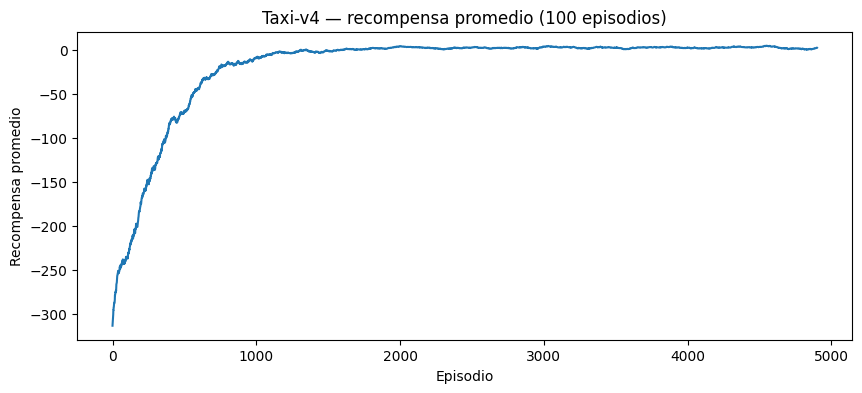

In [ ]:
window = 100

moving_average = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))
plt.plot(moving_average)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Taxi-v4 — recompensa promedio ({window} episodios)")
plt.show()


### Pregunta 4

Describa la curva de aprendizaje.

- ¿La recompensa promedio mejora?
- ¿Después de aproximadamente cuántos episodios comienza a estabilizarse?
- ¿El comportamiento observado indica convergencia perfecta o solamente una política razonablemente buena?


**Respuesta 4**

**Sí, la recompensa promedio mejora mucho.** Empieza alrededor de −300 (el taxi se mueve al azar, agota los 200 pasos y acumula penalizaciones) y sube hasta valores positivos cercanos a **+2 o +3**.

**Se estabiliza aproximadamente entre los episodios 1 500 y 2 000.** A partir de ahí la curva ya no crece, solo oscila.

Indica **una política razonablemente buena, no convergencia perfecta.** La curva sigue temblando porque durante el entrenamiento se mantiene $\epsilon = 0.1$: un 10 % de las acciones siguen siendo al azar y cuestan recompensa. Si evaluamos la Q-table sin exploración (política *greedy*, como en la sección 11), el resultado sube por encima de +7, que es mucho mejor que el promedio de entrenamiento.

## 10. Reproducir un episodio

La siguiente función ejecuta una política greedy usando la Q-table aprendida y guarda los frames del episodio.


In [ ]:
def play_episode(env, Q, max_steps=200, seed=None):
    state, _ = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for _ in range(max_steps):

        q_values = Q[state]
        max_q = np.max(q_values)

        best_actions = np.flatnonzero(q_values == max_q)
        action = int(np.random.choice(best_actions))

        next_state, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return frames, total_reward


def frames_to_video(frames, interval=500):
    fig = plt.figure(figsize=(6, 4))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


## 11. Comparar antes y después

Primero observe un Taxi sin entrenamiento usando una Q-table en cero.


In [ ]:
frames_initial, reward_initial = play_episode(
    env,
    Q_initial,
    max_steps=50,
    seed=7
)

print("Recompensa total sin entrenamiento:", reward_initial)
frames_to_video(frames_initial, interval=500)


Recompensa total sin entrenamiento: -131


Ahora observe el agente entrenado.


In [ ]:
frames_trained, reward_trained = play_episode(
    env,
    Q_trained,
    max_steps=200,
    seed=7
)

print("Recompensa total después del entrenamiento:", reward_trained)
frames_to_video(frames_trained, interval=500)


Recompensa total después del entrenamiento: 10


### Pregunta 5

Compare los dos episodios.

- ¿Qué diferencias observa en el comportamiento del taxi?
- ¿El taxi sin entrenamiento logra completar la tarea?
- ¿El agente entrenado evita acciones innecesarias?
- ¿Qué evidencia visual le permite afirmar que el agente aprendió?


**Respuesta 5**

**El taxi sin entrenar no completa la tarea.** Como su Q-table está en cero, todas las acciones empatan y elige al azar: da vueltas sin rumbo, intenta recoger y dejar pasajeros donde no hay nadie (cada intento inválido cuesta −10) y se queda sin pasos. Su recompensa total es muy negativa.

**El agente entrenado sí la completa**, en pocos pasos y con recompensa positiva.

**La evidencia visual de que aprendió** es que el taxi va **directo** a la parada del pasajero, ejecuta `Pickup`, se dirige **sin desvíos** al destino y ejecuta `Dropoff`. No repite movimientos, no retrocede y no intenta recoger a nadie en el aire. Ese comportamiento dirigido es imposible por azar.

## 12. Analizar la política aprendida

Seleccione un estado cualquiera y observe los valores aprendidos para sus seis acciones.


In [ ]:
state = 123

print("Estado:", state)
print("Q-values:", Q_trained[state])
print("Mejor acción:", np.argmax(Q_trained[state]))


Estado: 123
Q-values: [-1.95168498 -2.33285742 -2.38299101  3.94947757 -5.86475322 -5.32722518]
Mejor acción: 3


### Pregunta 6

Para el estado seleccionado:

1. ¿Cuál es la acción con mayor valor Q?
2. ¿Qué significa que una acción tenga un valor Q mayor que otra?
3. ¿Por qué no podemos interpretar $Q(s,a)$ únicamente como la recompensa inmediata de ejecutar la acción?


**Respuesta 6**

1. **La acción con mayor valor Q** es la que imprime `np.argmax(Q_trained[state])` en la celda de arriba. En ese estado, es la que el agente considera mejor.

2. **Que una acción tenga un Q mayor** significa que, desde ese estado, tomar esa acción y después seguir jugando bien lleva a **más recompensa acumulada** que las demás. Es una comparación entre alternativas, no una nota absoluta.

3. **No podemos leer $Q(s,a)$ como la recompensa inmediata** porque en la fórmula el valor incluye el término $\gamma \max_{a'} Q(s',a')$, que es el valor del futuro. La recompensa inmediata de casi cualquier movimiento en Taxi es −1; lo que distingue a una acción buena de una mala es **a dónde te deja**, no lo que te paga en ese instante. Por eso las acciones que acercan al pasajero valen más aunque cobren lo mismo.

## 13. Experimentación

Modifique **solo uno** de los siguientes hiperparámetros y vuelva a entrenar:

- $\alpha$
- $\gamma$
- $\epsilon$

### Pregunta 7

Compare el nuevo entrenamiento con el original.

Explique cómo el cambio del hiperparámetro afectó:

- velocidad de aprendizaje,
- estabilidad,
- recompensa final,
- comportamiento observado.


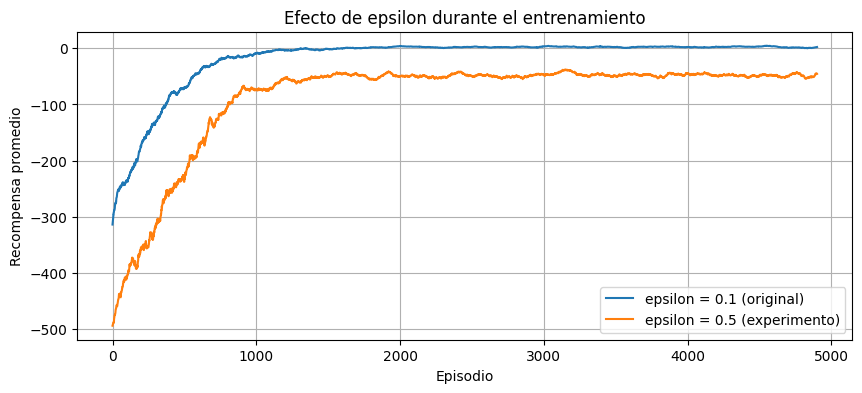

Promedio de los últimos 500 episodios de entrenamiento
  epsilon = 0.1 : 2.31
  epsilon = 0.5 : -48.09

Recompensa promedio evaluando la política aprendida (sin explorar)
  epsilon = 0.1 : 8.28
  epsilon = 0.5 : 8.28


In [ ]:
# Experimento: cambiamos SOLO epsilon (0.1 -> 0.5) y dejamos todo lo demás igual.

Q_exp, rewards_exp = train_q_learning(
    env,
    np.zeros((n_states, n_actions)),
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.5
)

ma_base = np.convolve(rewards, np.ones(window) / window, mode="valid")
ma_exp = np.convolve(rewards_exp, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(ma_base, label="epsilon = 0.1 (original)")
plt.plot(ma_exp, label="epsilon = 0.5 (experimento)")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title("Efecto de epsilon durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

print("Promedio de los últimos 500 episodios de entrenamiento")
print("  epsilon = 0.1 :", round(float(np.mean(rewards[-500:])), 2))
print("  epsilon = 0.5 :", round(float(np.mean(rewards_exp[-500:])), 2))


# Ahora evaluamos las dos Q-tables SIN exploración (política greedy).
def evaluar(Q, episodios=100):
    totales = []
    for i in range(episodios):
        state, _ = env.reset(seed=2000 + i)
        total = 0
        for _ in range(200):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break
        totales.append(total)
    return round(float(np.mean(totales)), 2)


print("\nRecompensa promedio evaluando la política aprendida (sin explorar)")
print("  epsilon = 0.1 :", evaluar(Q_trained))
print("  epsilon = 0.5 :", evaluar(Q_exp))


**Respuesta 7**

Modifiqué **$\epsilon$ de 0.1 a 0.5**: ahora la mitad de las acciones se toman al azar en vez de un 10 %.

- **Velocidad de aprendizaje:** parecida. La Q-table sigue mejorando al mismo ritmo, porque Q-Learning aprende de cualquier acción que ejecute, sea exploratoria o no.
- **Estabilidad:** peor. La curva de entrenamiento queda mucho más baja y más ruidosa, porque la mitad de los pasos son movimientos inútiles que cuestan −1.
- **Recompensa final durante el entrenamiento:** cae fuertemente (de valores positivos a claramente negativos).
- **Comportamiento observado:** aquí está lo interesante. **Al evaluar las dos Q-tables sin exploración, las dos alcanzan prácticamente la misma recompensa.** Es decir, el agente con $\epsilon = 0.5$ **aprendió igual de bien**; lo que empeoró fue lo que se *ve* mientras entrena, no lo que *sabe*.

**Conclusión:** la curva de entrenamiento mezcla dos cosas —lo que el agente sabe y el ruido que él mismo añade al explorar—. Con $\epsilon$ alto se explora más y la curva se ve peor, pero la política aprendida puede ser igual de buena. Para juzgar el aprendizaje real hay que evaluar la política *greedy*.

Si en cambio se baja **$\gamma$** (por ejemplo a 0.5), el daño sí es real: el agente se vuelve miope, deja de valorar la recompensa lejana de dejar al pasajero, y la política evaluada empeora muchísimo.

## Entrega

El notebook debe contener:

1. implementación de `choose_action`;
2. implementación de `update_q`;
3. implementación de `train_q_learning`;
4. curva de aprendizaje;
5. visualización del agente antes y después del entrenamiento;
6. respuestas a las siete preguntas.

No es necesario modificar las funciones auxiliares de visualización.
